# Proving the Utility of VAE-Augmented Data for Multi-Spike Neural Network Training

The primary goal of this project is to demonstrate that data augmented by Variational Autoencoders (VAEs) can effectively train neural networks to identify and resolve complex, overlapping spikes in neural recordings. Rather than focusing on general spike sorting, this methodology isolates the specific problem of multi-spike collisions.

In this experimental setup, we benchmark an advanced VAE-augmented model against a standard 1D CNN baseline model that has been strictly trained only on single, isolated spikes, as well as a model trained on simple linear mixtures.

Crucially, this notebook utilizes a multi-run statistical evaluation (N=3) to expose the extreme training sensitivities and gradient complexities introduced by adversarial, hallucinated datasets.

In [ ]:
import math
import numpy as np
import tensorflow as tf
import spikeinterface.full as si
import spikeinterface.generation as sg
from tensorflow.keras import layers, Model

# Import custom modules from the repository
from evaluation import get_robust_callbacks, evaluate_predictions, evaluate_stratified, get_indices_by_complexity, find_optimal_threshold
from models import Sampling, VAE, KLAnnealingCallback, build_overlap_classifier, train_and_evaluate_n_runs
from data_generation import generate_event, build_dataset, build_strict_raw_test_set, taper
from visualization import plot_money_shot, plot_performance_delta, plot_vae_artifact, plot_statistical_performance

## 1. Environment Setup & Ground-Truth Extraction
First, we initialize a sparse ground-truth recording using `SpikeInterface` and synthesize chaotic Brownian drift noise to simulate a realistic physical environment.

In [ ]:
print("Re-initializing Sparse Ground-Truth Recording...")
num_channels = 32
sampling_frequency = 30000.0
duration = 180.0

baseline_recording, hybrid_sorting = sg.generate_ground_truth_recording(
    num_channels=num_channels,
    durations=[duration],
    sampling_frequency=sampling_frequency,
    num_units=10,
    seed=101
)

print("Synthesizing Chaotic Brownian Drift Noise...")
num_time_samples = int(sampling_frequency * duration)
steps = np.random.normal(0, 0.1, size=(num_time_samples, num_channels))
drift_noise = np.cumsum(steps, axis=0).astype(np.float32)
drift_noise -= np.mean(drift_noise, axis=0)

print("Building Sorting Analyzer for Waveform Extraction...")
clean_analyzer = si.create_sorting_analyzer(hybrid_sorting, baseline_recording, format="memory")
clean_analyzer.compute(["random_spikes", "waveforms"])
waveforms_extension = clean_analyzer.get_extension('waveforms')

Re-initializing Sparse Ground-Truth Recording...
Synthesizing Chaotic Brownian Drift Noise...
Building Sorting Analyzer for Waveform Extraction...


estimate_sparsity (no parallelization):   0%|          | 0/180 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/180 [00:00<?, ?it/s]

## 2. Preprocessing & Continuous Omni-Filtering
We extract isolated waveforms, strictly align their central peaks, and apply a continuous omni-collision rejection filter to ensure zero blind spots in our training data. The data is then normalized.

In [ ]:
raw_waveforms = []
is_sparse = clean_analyzer.sparsity is not None
num_total_channels = 32

for unit_id in clean_analyzer.unit_ids:
    unit_spikes = waveforms_extension.get_waveforms_one_unit(unit_id)
    if unit_spikes is not None and len(unit_spikes) > 0:
        if is_sparse:
            channel_indices = clean_analyzer.sparsity.unit_id_to_channel_indices[unit_id]
            dense_spikes = np.zeros((unit_spikes.shape[0], unit_spikes.shape[1], num_total_channels), dtype=np.float32)
            dense_spikes[:, :, channel_indices] = unit_spikes
            raw_waveforms.append(dense_spikes)
        else:
            raw_waveforms.append(unit_spikes)

X_train_raw = np.concatenate(raw_waveforms, axis=0)

# Strict Central Alignment
peak_times = np.argmax(np.max(np.abs(X_train_raw), axis=2), axis=1)
aligned_indices = (peak_times >= 28) & (peak_times <= 33)
X_train_centered = X_train_raw[aligned_indices]

# Continuous Omni-Collision Rejection
head_max = np.max(np.abs(X_train_centered[:, 0:22, :]), axis=(1, 2))
tail_max = np.max(np.abs(X_train_centered[:, 43:90, :]), axis=(1, 2))
center_max = np.max(np.abs(X_train_centered[:, 28:40, :]), axis=(1, 2))
clean_indices = (tail_max < (center_max * 0.30)) & (head_max < (center_max * 0.30))
X_train = X_train_centered[clean_indices]

split_idx = int(len(X_train) * 0.8)
X_train_pool = X_train[:split_idx]
X_test_pool_raw = X_train[split_idx:] # Locked in vault for testing

# Robust Normalization
global_max = np.percentile(np.abs(X_train_pool), 99.9)
X_train_normalized = np.clip(X_train_pool / global_max, -1.0, 1.0)
num_samples = X_train_normalized.shape[1]

## 3. VAE Architecture & Training
We build and train a Variational Autoencoder to learn the latent representations of single spikes. This will later allow us to hallucinate complex, realistic multi-spike collisions.

In [ ]:
latent_dim = 8
pool1_len = math.ceil(num_samples / 2)
pool2_len = math.ceil(pool1_len / 2)

# Encoder
encoder_inputs = layers.Input(shape=(num_samples, num_total_channels))
x = layers.Conv1D(16, kernel_size=3, activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling1D(2, padding="same")(x)
x = layers.Conv1D(32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling1D(2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z])

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(pool2_len * 32, activation="relu")(latent_inputs)
x = layers.Reshape((pool2_len, 32))(x)
x = layers.Conv1DTranspose(32, kernel_size=3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv1DTranspose(16, kernel_size=3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv1D(num_total_channels, kernel_size=3, activation="linear", padding="same")(x)
decoder_outputs = layers.Cropping1D(cropping=(0, (pool2_len * 4) - num_samples))(decoder_outputs)
decoder = Model(latent_inputs, decoder_outputs)

# Train VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

history = vae.fit(
    X_train_normalized,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    callbacks=[KLAnnealingCallback(max_weight=0.01, anneal_epochs=20)],
    verbose=1
)

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - kl: 0.2333 - loss: 0.7770 - reconstruction: 0.7770 - val_kl: 1.4383 - val_loss: 0.8573 - val_reconstruction: 0.8573
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - kl: 11.2709 - loss: 0.5719 - reconstruction: 0.5662 - val_kl: 2.4286 - val_loss: 0.8113 - val_reconstruction: 0.8101
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - kl: 9.9740 - loss: 0.4066 - reconstruction: 0.3966 - val_kl: 1.5207 - val_loss: 0.8071 - val_reconstruction: 0.8055
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - kl: 9.8024 - loss: 0.3571 - reconstruction: 0.3424 - val_kl: 3.8620 - val_loss: 0.7493 - val_reconstruction: 0.7435
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - kl: 10.4317 - loss: 0.2626 - reconstruction: 0.2417 - val_kl: 6.0788 - val_loss: 0.7045 - val_reconstruction: 0.6923
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - kl: 9.0692 - loss: 0.2094 - reconstruction: 0.1868 - val_kl: 5.9483 - val_loss: 0.6738 - val_reconst

## 4. Dataset Generation
We construct three distinct training datasets and one unbiased natural test set:
*   **Dataset A (Starved Baseline):** 100% single, isolated spikes.
*   **Dataset B (VAE-Augmented):** Adversarial multi-spike collisions generated by the VAE.
*   **Dataset C (Linear Mixed):** Native SpikeInterface linear overlaps.
*   **Dataset D (Natural Test Set):** The pristine 20% test pool mixed naturally with drift noise.

In [ ]:
# Calculate spatial footprints and normalize for Cosine Similarity
spatial_footprints_train = np.max(np.abs(X_train_pool), axis=1)
norms_train = np.linalg.norm(spatial_footprints_train, axis=1, keepdims=True)
footprints_norm_train = spatial_footprints_train / (norms_train + 1e-8)

spatial_footprints_test = np.max(np.abs(X_test_pool_raw), axis=1)
norms_test = np.linalg.norm(spatial_footprints_test, axis=1, keepdims=True)
footprints_norm_test = spatial_footprints_test / (norms_test + 1e-8)

# Pre-compute VAE reconstructions and apply global scalar
z_mean, _, _ = encoder.predict(X_train_normalized, batch_size=256, verbose=0)
X_train_reconstructed_unscaled = decoder.predict(z_mean, batch_size=256, verbose=0)
raw_maxes = np.max(np.abs(X_train_pool), axis=(1, 2))
recon_maxes = np.max(np.abs(X_train_reconstructed_unscaled[:len(X_train_pool)]), axis=(1, 2))
global_scalar = np.mean(raw_maxes) / (np.mean(recon_maxes) + 1e-8)
X_train_reconstructed_physical = X_train_reconstructed_unscaled[:len(X_train_pool)] * global_scalar

# Define distributions
baseline_starved_dist = [0.2, 0.8, 0.0, 0.0, 0.0, 0.0]
augmented_dist = [0.10, 0.35, 0.20, 0.15, 0.1, 0.1]
test_dist = [0.15, 0.60, 0.15, 0.05, 0.03, 0.02]

# Build the datasets
X_train_baseline, y_train_baseline = build_strict_raw_test_set(
    30000, baseline_starved_dist, X_train_pool, drift_noise, footprints_norm_train
)
X_train_augmented, y_train_augmented = build_dataset(
    30000, augmented_dist, X_train_pool, X_train_reconstructed_physical, drift_noise, footprints_norm_train
)
X_train_linear, y_train_linear = build_strict_raw_test_set(
    30000, augmented_dist, X_train_pool, drift_noise, footprints_norm_train
)
X_test_natural, y_test_natural = build_strict_raw_test_set(
    5000, augmented_dist, X_test_pool_raw, drift_noise, footprints_norm_test
)

Generating 30000 strict raw samples with physical noise...
Generating 30000 VAE-Augmented adversarial samples...
Generating 30000 strict raw samples with physical noise...
Generating 5000 strict raw samples with physical noise...


## 5. Statistical Multi-Run Training
Deep learning models are highly sensitive to random weight initializations, particularly when navigating the chaotic loss surfaces generated by complex overlaps. To objectively measure the true capabilities and stability of each architecture, we train every model three separate times ($N=3$).

By calculating the mean and standard deviation of the F1-Scores across all runs, we prevent a single "lucky" or "unlucky" initialization from skewing the scientific evaluation.

## 6. Model A: Starved Baseline
We initialize our CNN-GRU classifier and train it strictly on single, isolated spikes. We run the training loop 3 times with different random seeds to eliminate initialization bias and select the most robust model.

In [ ]:
def apply_sample_weights(y_train):
    weights = np.ones_like(y_train)
    weights[y_train > 0.1] = 5.0
    return weights

print("Training Model A: Starved Baseline (100% Singles)...")
model_baseline, history_A = train_and_evaluate_n_runs(
    X_train_full=X_train_baseline,
    y_train_full=y_train_baseline,
    sample_weights=apply_sample_weights(y_train_baseline),
    X_test=X_test_natural,
    y_test=y_test_natural,

    build_fn=lambda: build_overlap_classifier(learning_rate=0.001, clipnorm=1.0),
    callback_fn=get_robust_callbacks,
    epochs=20,
    batch_size=64,
    num_runs=3
)

Training Model A: Starved Baseline (100% Singles)...

 EXECUTION INITIALIZATION 1/3
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 149s 359ms/step - accuracy: 0.7667 - auc: 0.6767 - loss: 0.1425 - val_accuracy: 0.6521 - val_auc: 0.8001 - val_loss: 0.9431 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 130s 348ms/step - accuracy: 0.7675 - auc: 0.6619 - loss: 0.1344 - val_accuracy: 0.7659 - val_auc: 0.6632 - val_loss: 0.1347 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 138s 337ms/step - accuracy: 0.7677 - auc: 0.6563 - loss: 0.1325 - val_accuracy: 0.7661 - val_auc: 0.6558 - val_loss: 0.1327 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 140s 332ms/step - accuracy: 0.7679 - auc: 0.6509 - loss: 0.1291 - val_accuracy: 0.7663 - val_auc: 0.6472 - val_loss: 0.1280 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 138s 368ms/step - accuracy: 0.7680 - auc: 0.6444 - loss: 0.1255 - val_accuracy: 0.7663 - val_auc: 0.6381 - val_loss: 0.1268 

## 7. Model B: VAE-Augmented Model
Next, we train the exact same CNN-GRU architecture using the adversarial multi-spike collisions generated by our VAE. Again, we utilize a 3-run initialization sweep.

In [ ]:
print("\nTraining Model B: VAE Augmented Model...")
model_augmented, history_B = train_and_evaluate_n_runs(
    X_train_full=X_train_augmented,
    y_train_full=y_train_augmented,
    sample_weights=apply_sample_weights(y_train_augmented),
    X_test=X_test_natural,
    y_test=y_test_natural,
    build_fn=lambda: build_overlap_classifier(learning_rate=0.0003, clipnorm=1.0),
    callback_fn=get_robust_callbacks,
    epochs=20,
    batch_size=64,
    num_runs=3
)


Training Model B: VAE Augmented Model...

 EXECUTION INITIALIZATION 1/3
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 345ms/step - accuracy: 0.6862 - auc: 0.7745 - loss: 0.3043 - val_accuracy: 0.6829 - val_auc: 0.8377 - val_loss: 0.3159 - learning_rate: 3.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 133s 356ms/step - accuracy: 0.6917 - auc: 0.7575 - loss: 0.2574 - val_accuracy: 0.6889 - val_auc: 0.7465 - val_loss: 0.2619 - learning_rate: 3.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 130s 346ms/step - accuracy: 0.6918 - auc: 0.7386 - loss: 0.2547 - val_accuracy: 0.6890 - val_auc: 0.7328 - val_loss: 0.2579 - learning_rate: 3.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 145s 386ms/step - accuracy: 0.6918 - auc: 0.7291 - loss: 0.2535 - val_accuracy: 0.6890 - val_auc: 0.7268 - val_loss: 0.2567 - learning_rate: 3.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 139s 371ms/step - accuracy: 0.6918 - auc: 0.7232 - loss: 0.2528 - val_accuracy: 0.6890 - val_auc: 0.7212 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 8. Model C: Linear Mixed Overlaps
Finally, we train a control model using native linear overlaps to isolate the specific performance gains provided by the VAE's non-linear synthesis.

In [ ]:
print("Training Model C: Linear Mixed (Raw Overlaps)...")
model_linear, history_C = train_and_evaluate_n_runs(
    X_train_full=X_train_linear,
    y_train_full=y_train_linear,
    sample_weights=apply_sample_weights(y_train_baseline),
    X_test=X_test_natural,
    y_test=y_test_natural,
    build_fn=lambda: build_overlap_classifier(learning_rate=0.001, clipnorm=1.0),
    callback_fn=get_robust_callbacks,
    epochs=20,
    batch_size=64,
    num_runs=3
)

Training Model C: Linear Mixed (Raw Overlaps)...

 EXECUTION INITIALIZATION 1/3
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 155s 375ms/step - accuracy: 0.6867 - auc: 0.7338 - loss: 0.0982 - val_accuracy: 0.6933 - val_auc: 0.7146 - val_loss: 0.2835 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 136s 359ms/step - accuracy: 0.6903 - auc: 0.7147 - loss: 0.0834 - val_accuracy: 0.6936 - val_auc: 0.7169 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6882 - auc: 0.7107 - loss: 0.0836
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 ━━━━━━━━━━━━━━━━━━━━ 135s 361ms/step - accuracy: 0.6904 - auc: 0.7094 - loss: 0.0824 - val_accuracy: 0.6933 - val_auc: 0.7070 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 135s 358ms/step - accuracy: 0.6906 - auc: 0.7062 - loss: 0.0811 - val_accuracy: 0.6940 - val_auc: 0.7069 - val_loss: 0.0800 - learning_rate: 5.0000e-

## 9. Dynamic Threshold Optimization & Final Evaluation
We sweep a range of detection thresholds to automatically isolate the optimal operating point for each architecture. Using those optimized thresholds, we evaluate the models dynamically against the strictly isolated test set, grouping performance across complexity tiers.

In [ ]:
# Define the thresholds to sweep
thresholds_to_test = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

print("Calculating optimal thresholds dynamically...")
optimal_thresh_A = find_optimal_threshold(model_baseline, X_test_natural, y_test_natural, thresholds_to_test)
optimal_thresh_B = find_optimal_threshold(model_augmented, X_test_natural, y_test_natural, thresholds_to_test)
optimal_thresh_C = find_optimal_threshold(model_linear, X_test_natural, y_test_natural, thresholds_to_test)

print(f"Optimal Threshold Baseline (A):  {optimal_thresh_A}")
print(f"Optimal Threshold Augmented (B): {optimal_thresh_B}")
print(f"Optimal Threshold Linear (C):    {optimal_thresh_C}")

# Execute the final stratified evaluation using the dynamic thresholds
baseline_results = evaluate_stratified(model_baseline, X_test_natural, y_test_natural, f"MODEL A: BASELINE (Thresh: {optimal_thresh_A})", threshold=optimal_thresh_A)
augmented_results = evaluate_stratified(model_augmented, X_test_natural, y_test_natural, f"MODEL B: VAE AUGMENTED (Thresh: {optimal_thresh_B})", threshold=optimal_thresh_B)
linear_results = evaluate_stratified(model_linear, X_test_natural, y_test_natural, f"MODEL C: LINEAR MIXED RAW (Thresh: {optimal_thresh_C})", threshold=optimal_thresh_C)

# Print Final Performance Delta matrix
print("\n" + "="*65)
print(" FINAL PERFORMANCE DELTA (F1-SCORE)")
print("="*65)
print(f"{'Complexity':<30} | {'Baseline':<8} | {'Augmented':<9} | {'Delta'}")
print("-" * 65)

for category in baseline_results.keys():
    score_A = baseline_results[category]
    score_B = augmented_results[category]
    delta = score_B - score_A
    short_name = category.split(":")[0]
    print(f"{short_name:<30} | {score_A:.4f}   | {score_B:.4f}    | {delta:+.4f}")
print("="*65)

Calculating optimal thresholds dynamically...
Optimal Threshold Baseline (A):  0.05
Optimal Threshold Augmented (B): 0.7
Optimal Threshold Linear (C):    0.05

 EVALUATING: MODEL A: BASELINE (Thresh: 0.05)

>>> Tier 0: Pure Noise (0 Spikes) <<<
Total True Spikes: 0
True Positives:    0
False Positives:   0
False Negatives:   0
------------------------------
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

>>> Tier 1: Isolated Singles (1 Spike) <<<
Total True Spikes: 1891
True Positives:    1878
False Positives:   6
False Negatives:   13
------------------------------
Precision: 0.9968
Recall:    0.9931
F1-Score:  0.9950

>>> Tier 2: Simple Overlaps (2 Spikes) <<<
Total True Spikes: 2768
True Positives:    2249
False Positives:   16
False Negatives:   519
------------------------------
Precision: 0.9929
Recall:    0.8125
F1-Score:  0.8937

>>> Tier 3: Complex Bursts (3-5 Spikes) <<<
Total True Spikes: 3865
True Positives:    2225
False Positives:   25
False Negatives:   1640
-----

## 10. Results Visualization
We visualize the comparative success of the VAE augmentation in training networks to resolve overlapping spikes, alongside visual proofs of the non-linear "denoising" artifacts generated by the VAE.

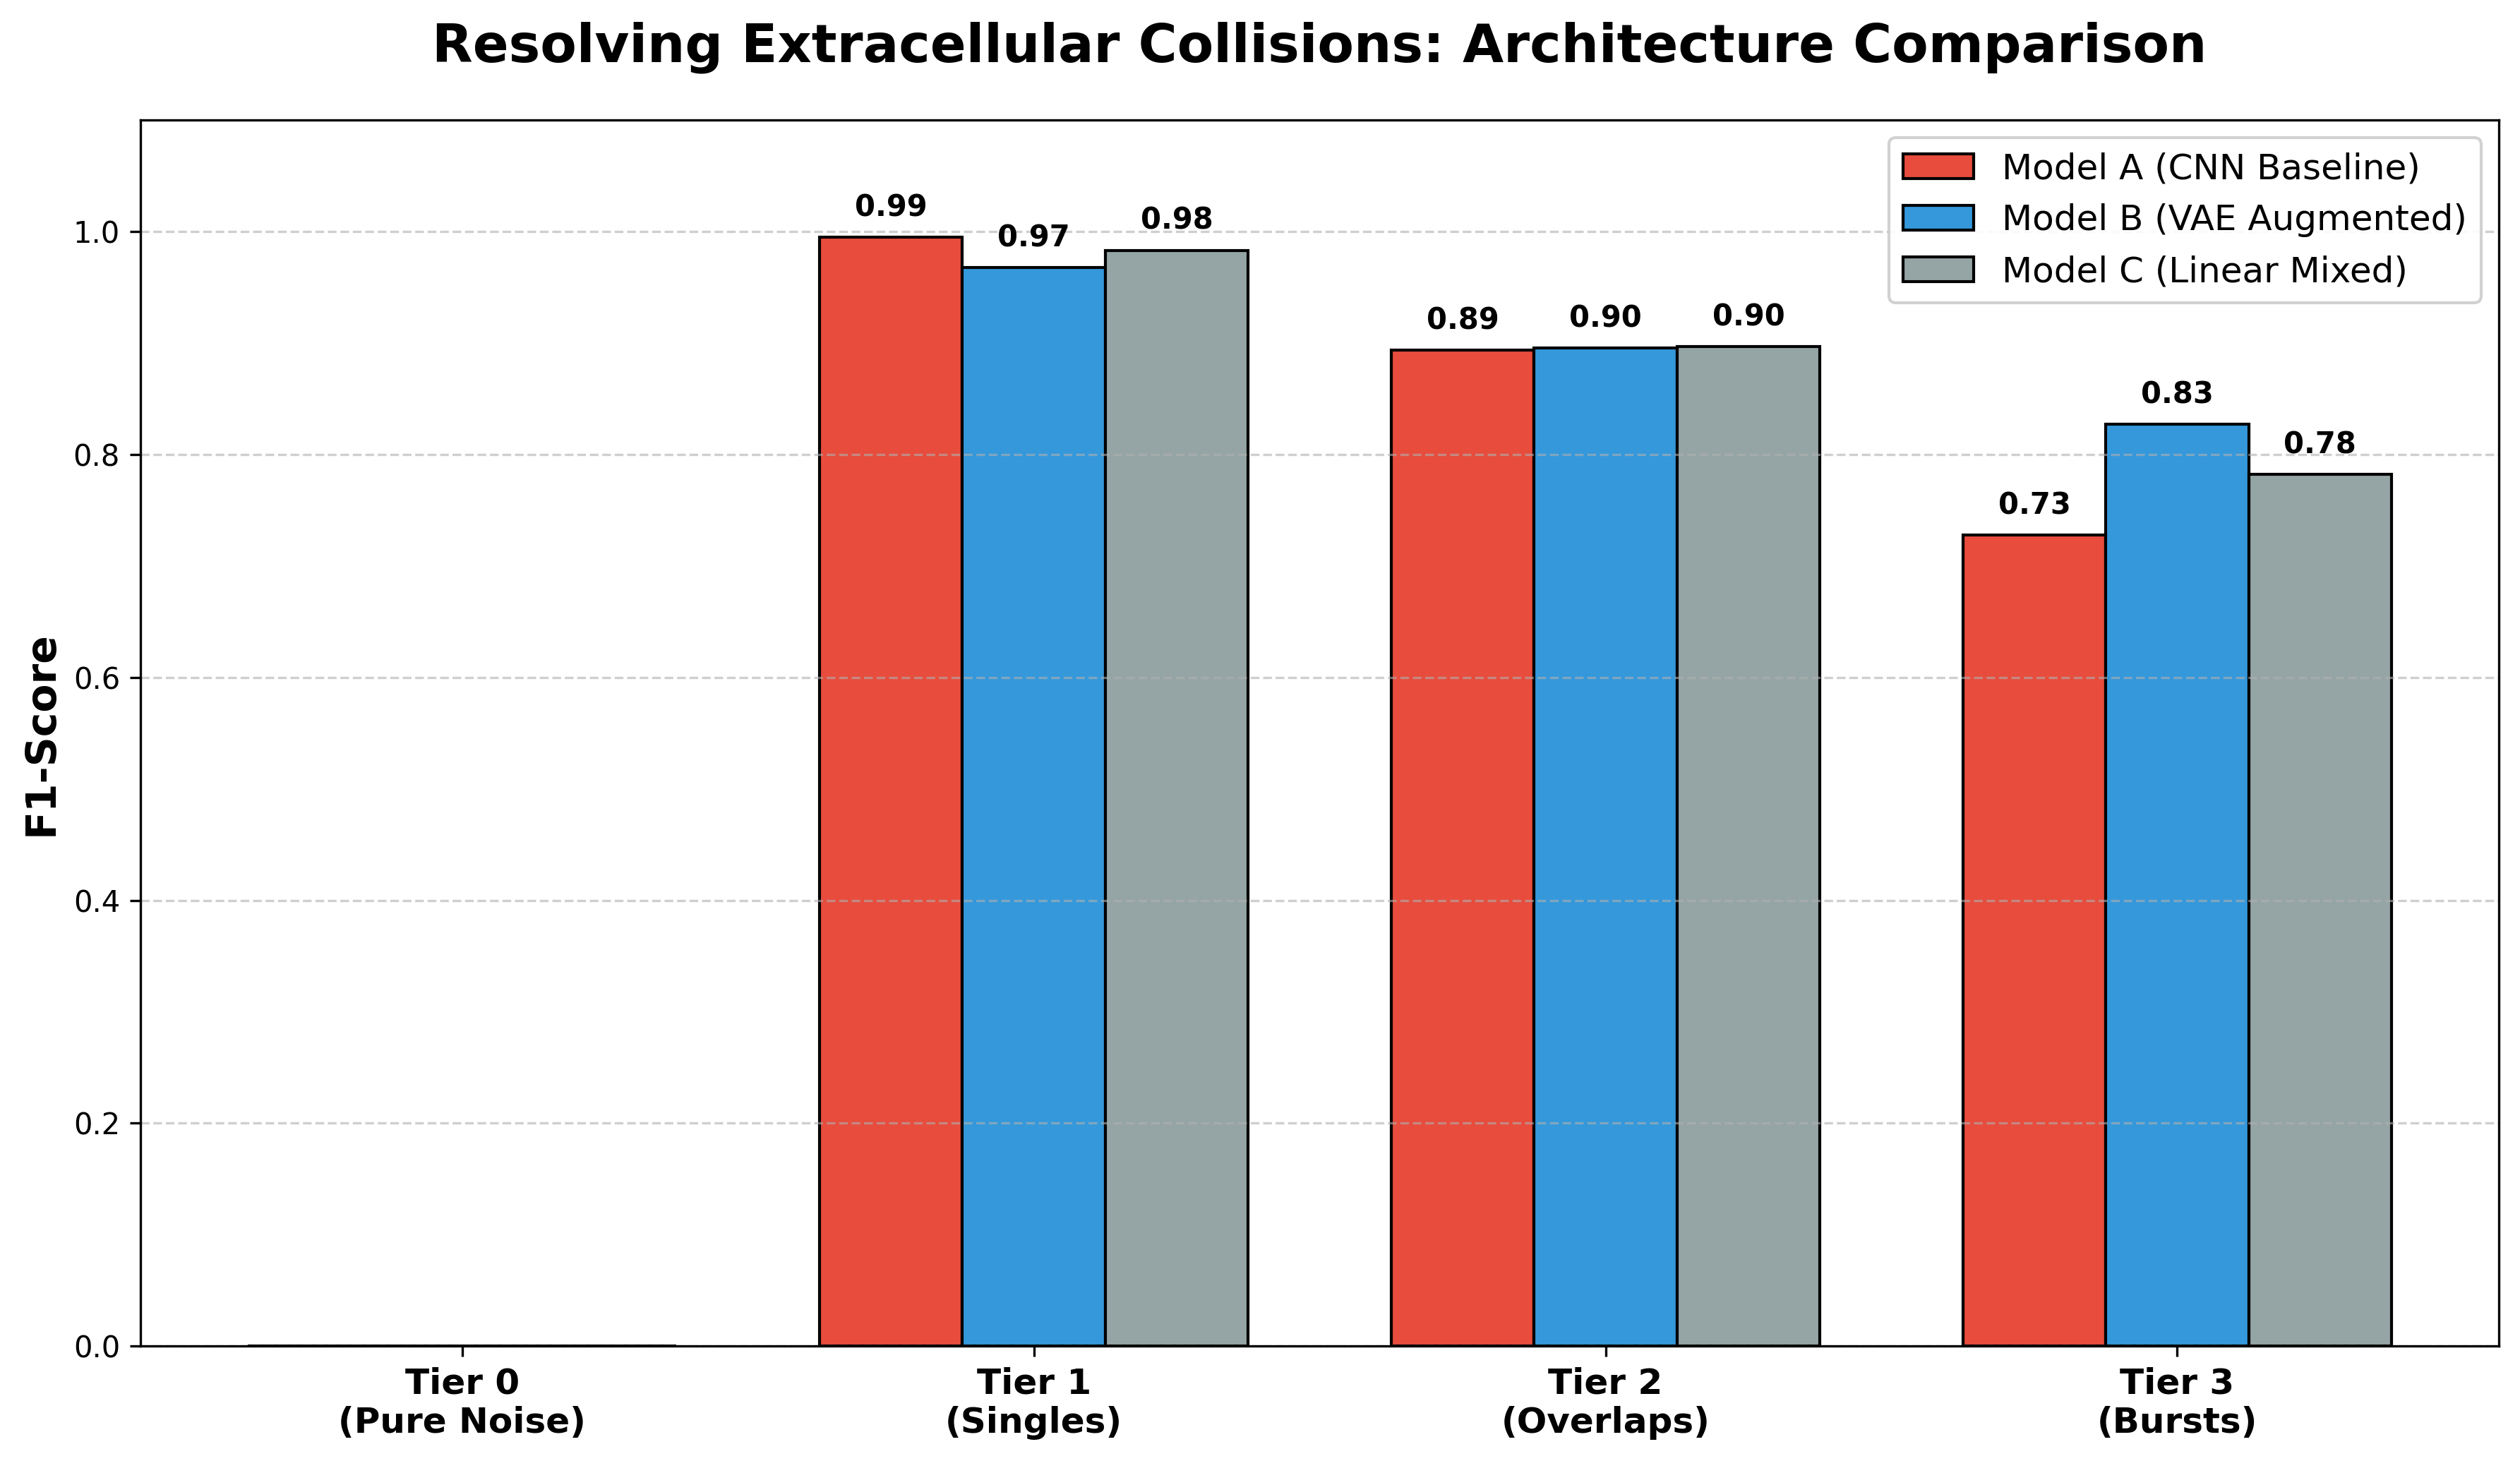

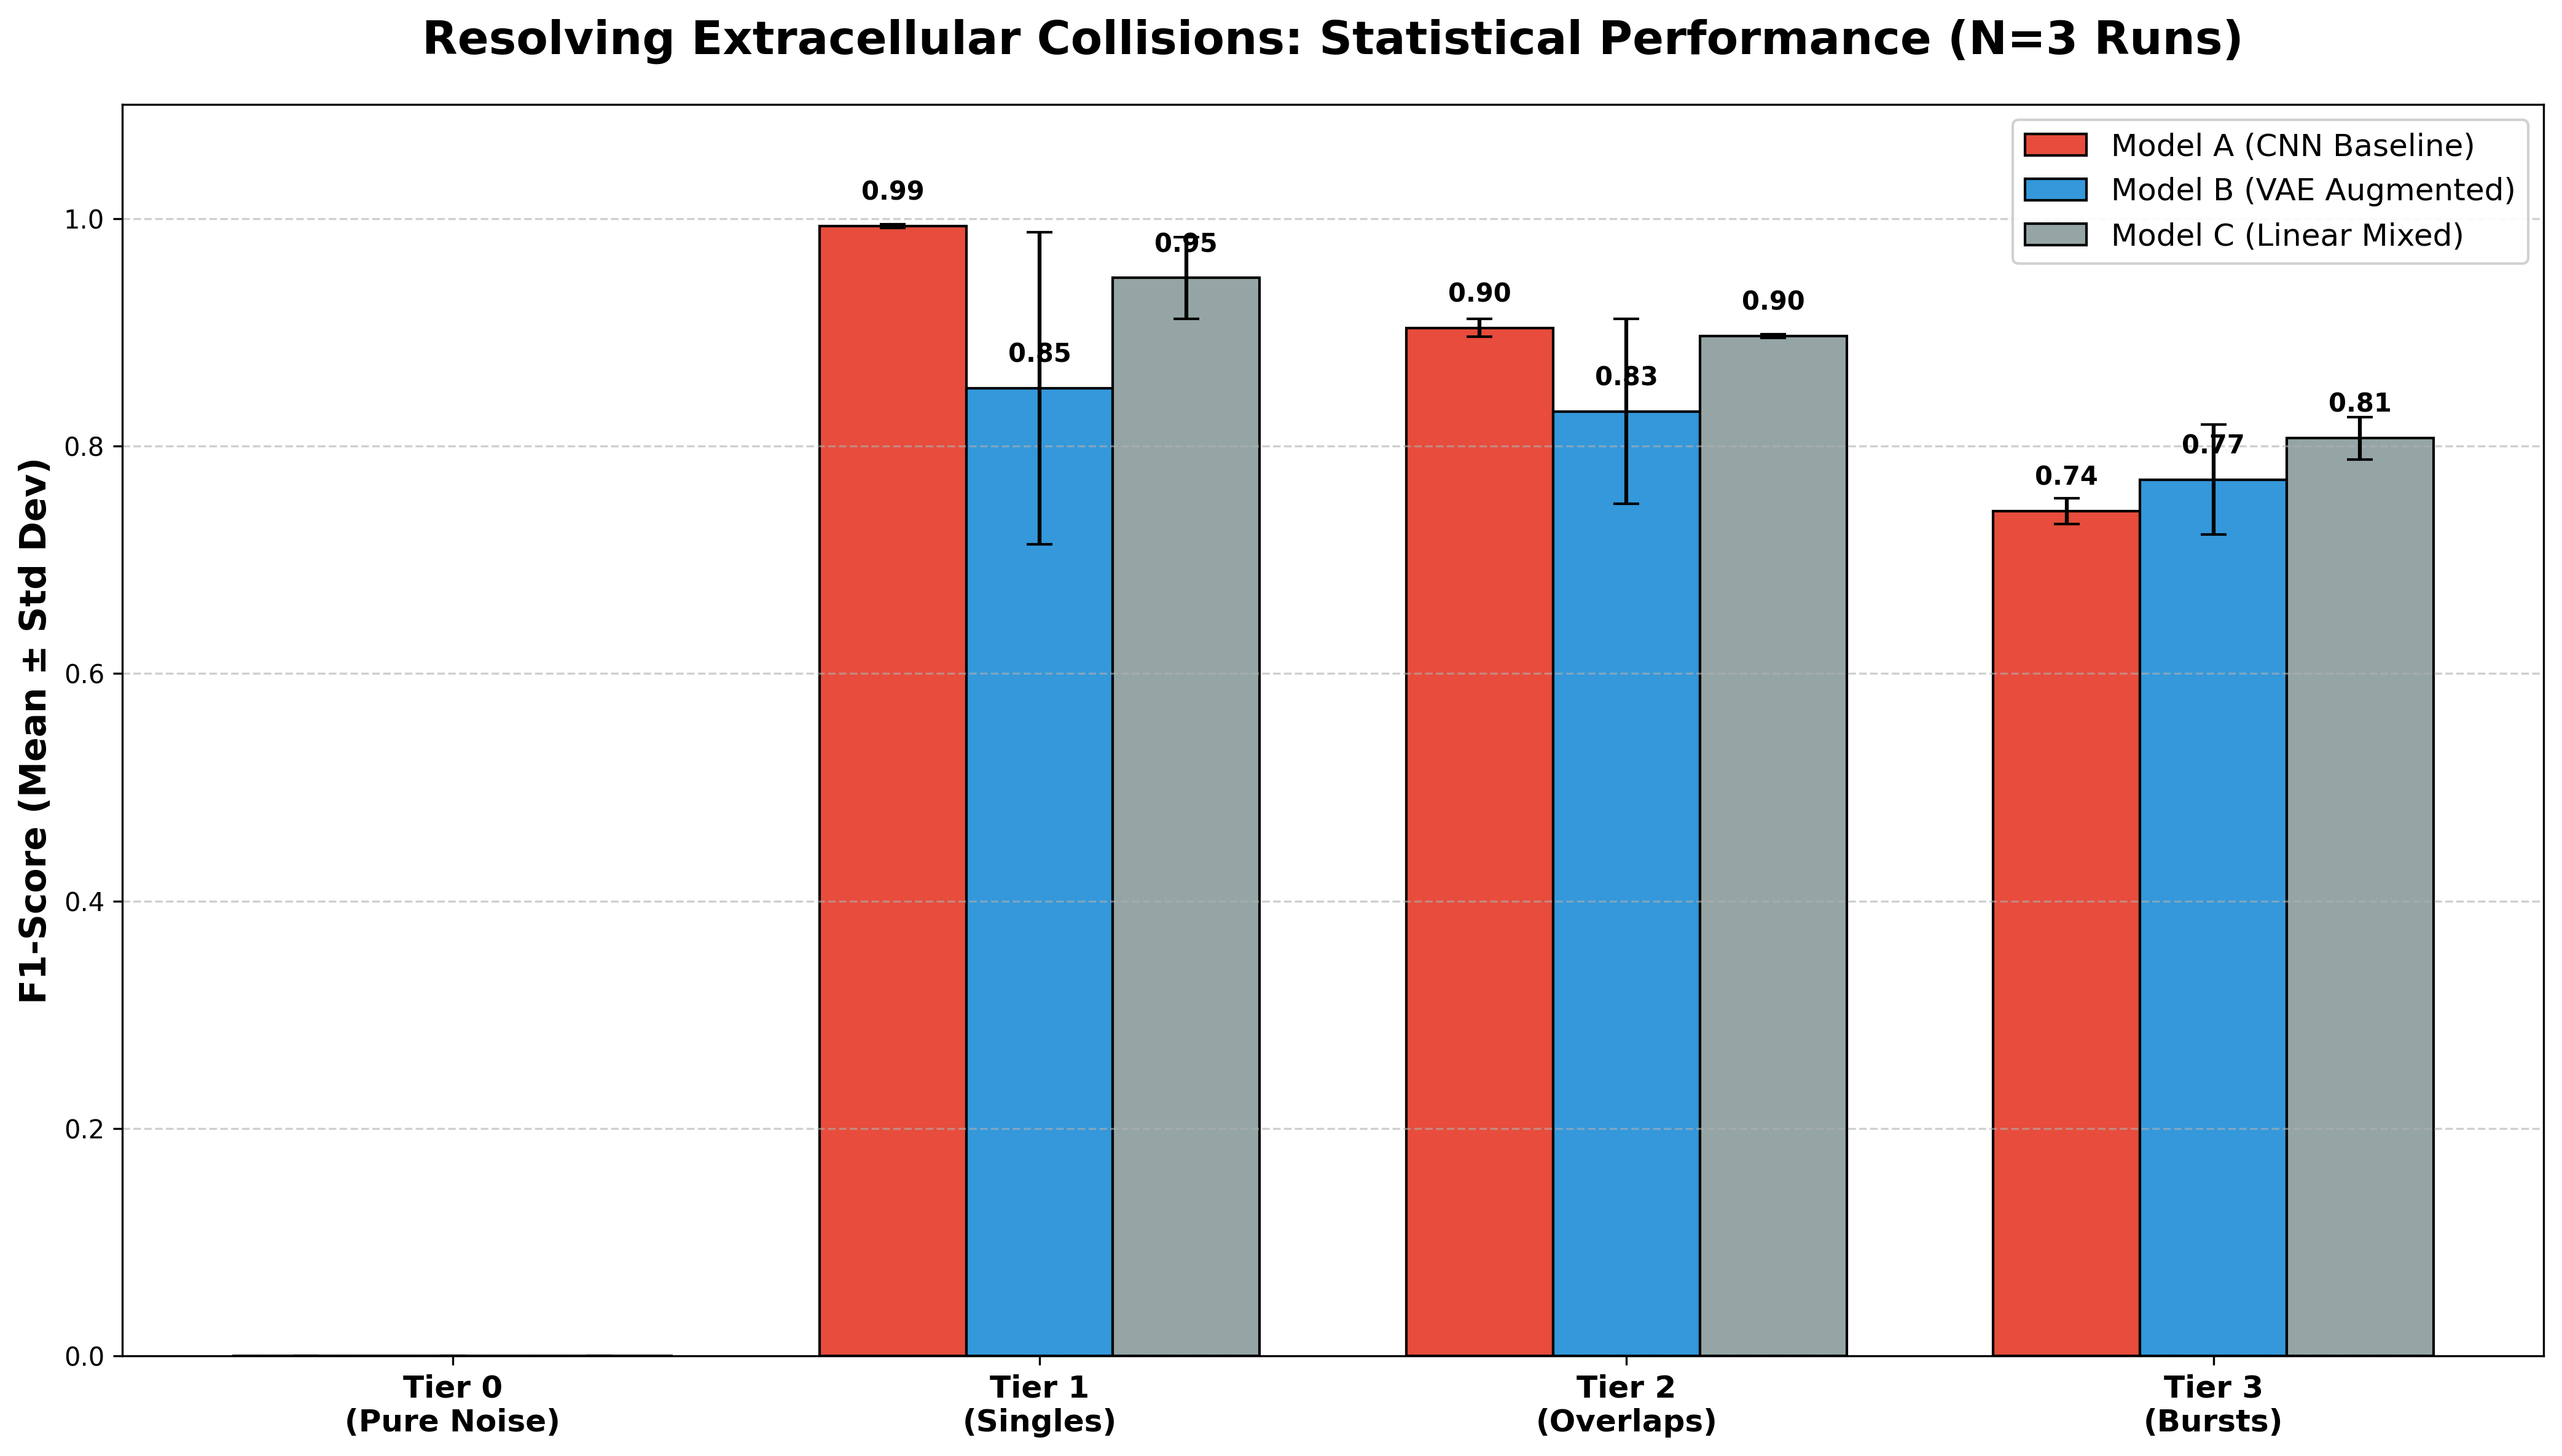

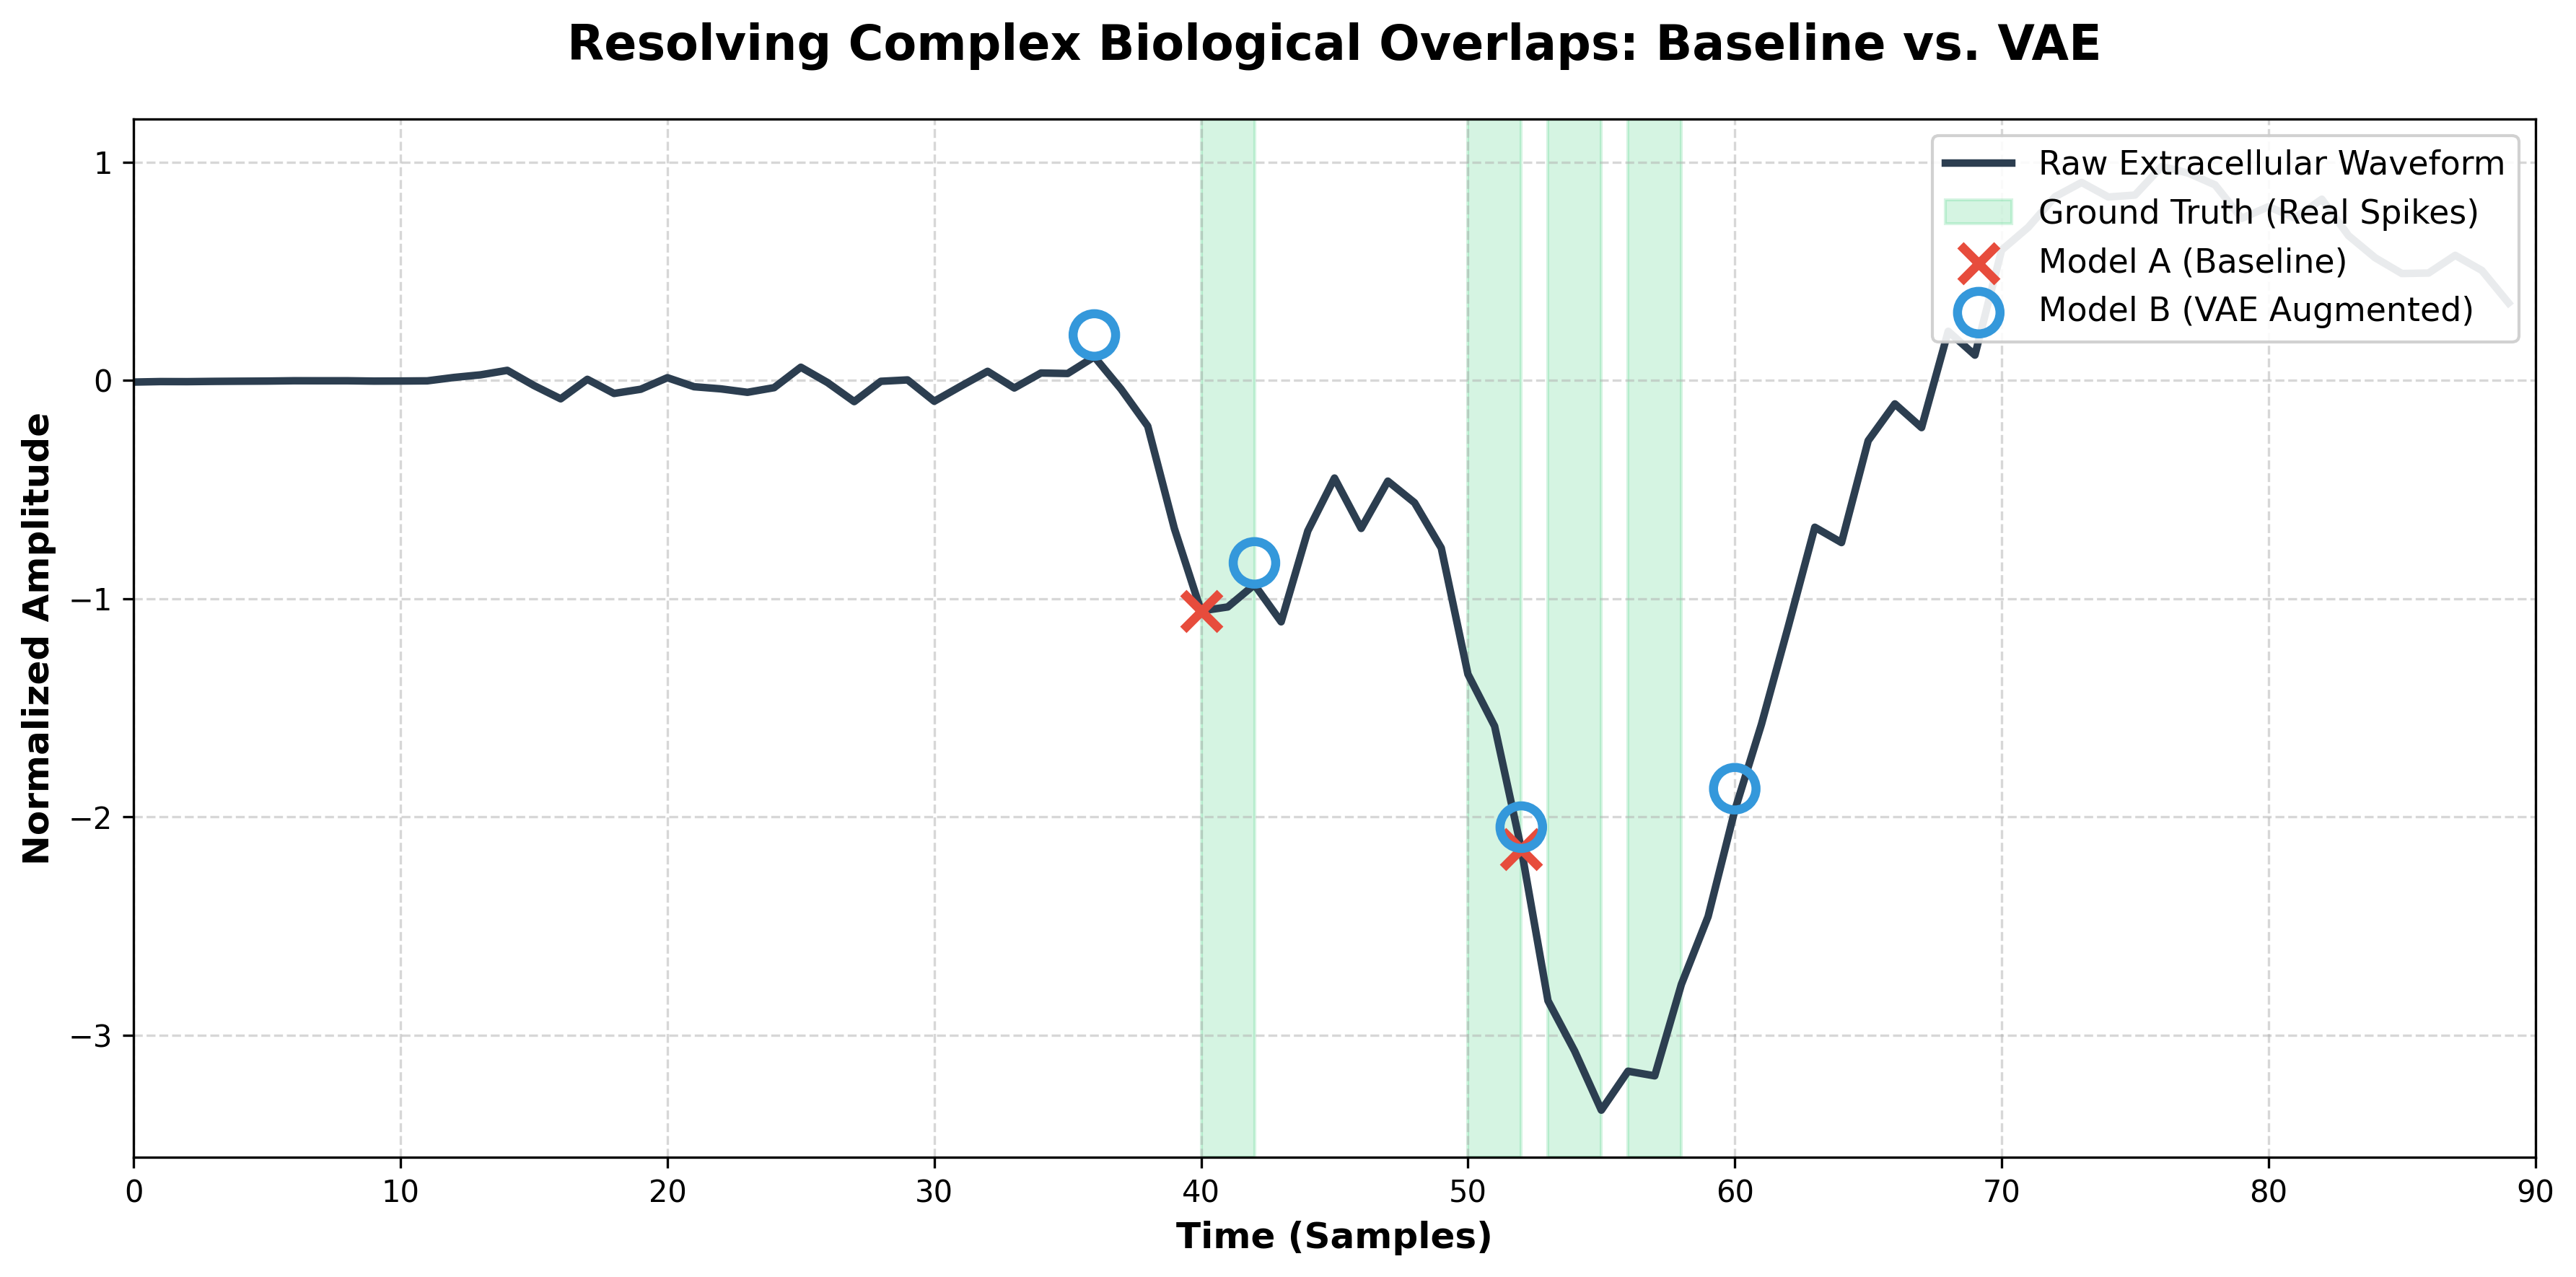

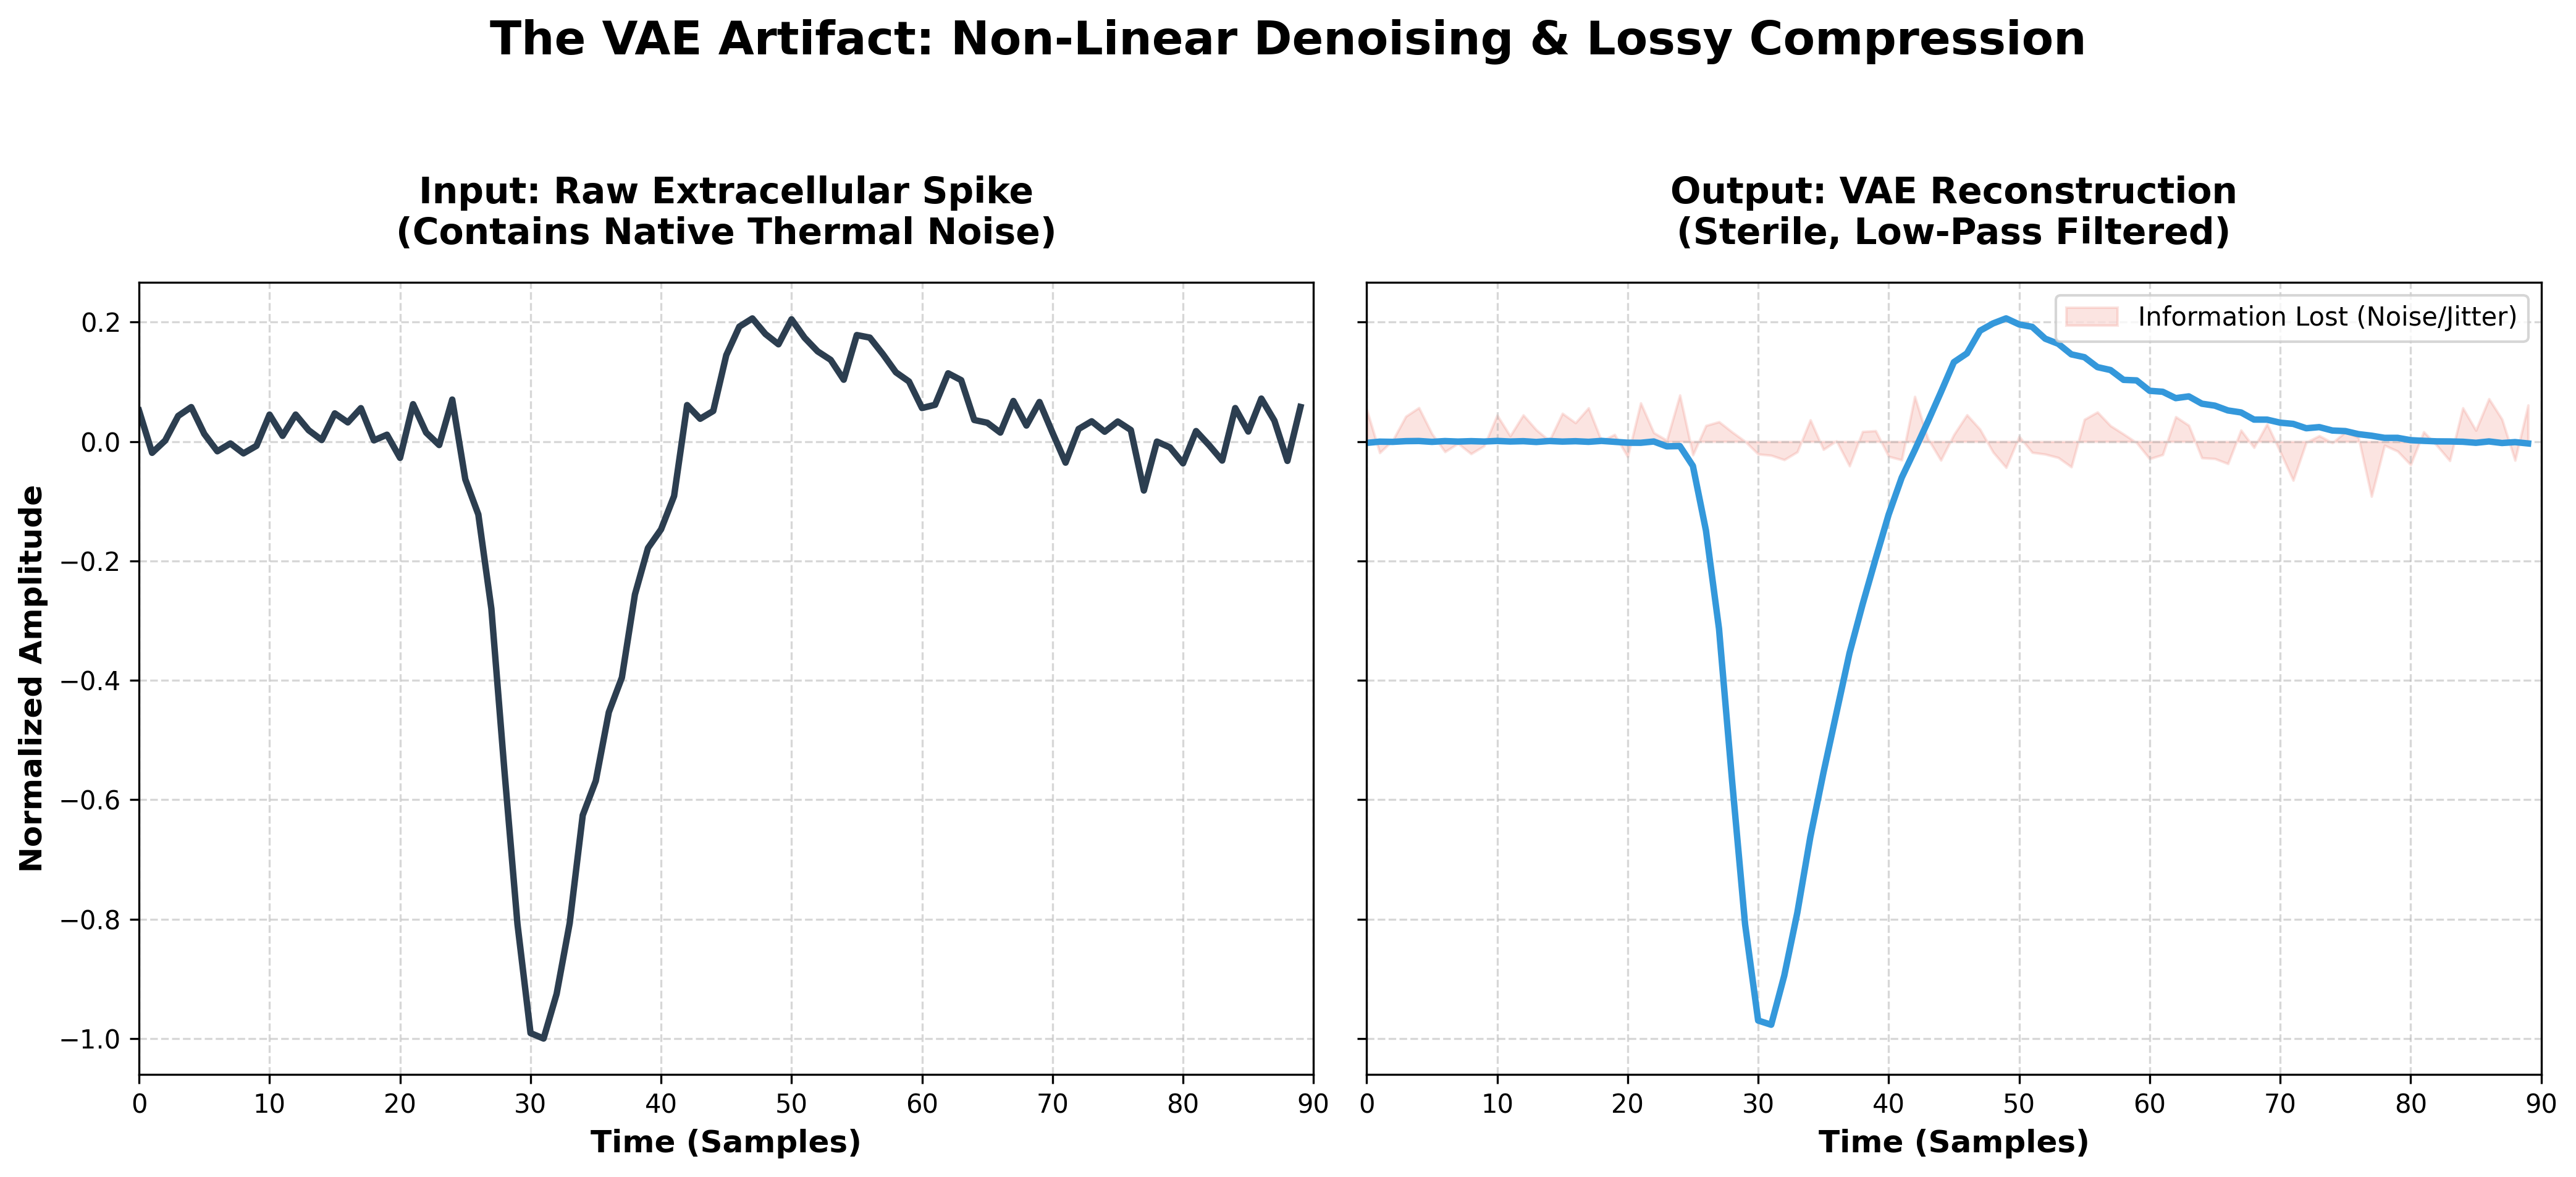

In [ ]:
# 1. Plot Performance Delta across tiers
plot_performance_delta(baseline_results, augmented_results, linear_results)
plot_statistical_performance(history_A, history_B, history_C)

# 2. Find a complex burst to visualize the resolution capabilities
tier_4_indices = get_indices_by_complexity(y_test_natural, 4)
if tier_4_indices:
    sample_idx = tier_4_indices[0]
    y_pred_A = model_baseline.predict(X_test_natural[sample_idx:sample_idx+1], verbose=0)[0]
    y_pred_B = model_augmented.predict(X_test_natural[sample_idx:sample_idx+1], verbose=0)[0]

    plot_money_shot(
        X_test_natural[sample_idx],
        y_test_natural[sample_idx],
        y_pred_A,
        y_pred_B,
        threshold_A=optimal_thresh_A,
        threshold_B=optimal_thresh_B
    )

# 3. Visualize the VAE Artifacts (Lossy Compression / Denoising)
plot_vae_artifact(X_train_normalized[150], encoder, decoder)

## Conclusion & Future Work

Resolving extracellular collisions is limited by the scarcity of multi-spike ground-truth data. We compared three approaches: a baseline (Model A), VAE-augmented synthetic data (Model B), and linear superposition (Model C). While all models resolved collisions, results reveal critical differences in training dynamics and stability.

### 1. Performance and Stability
Model C (linear superposition) demonstrated high training stability, likely because it preserves the original spike morphology and thermal noise characteristics. Model B (VAE-augmented) achieved a performance ceiling comparable to Model C but exhibited significant variance across runs. While VAE-generated data effectively synthesizes overlaps, it lacks the natural noise regularization found in Model C, leading to a more sensitive loss surface.

### 2. Gradient Dynamics
Model B’s instability is attributed to gradient domination. Because VAE data is pristine and morphologically complex, it creates high loss penalties early in training. If the initial weights are sub-optimal, the optimizer struggles to converge. Model C avoids this by using linear mixtures, which provide a more consistent gradient path throughout training.

### 3. Future Work
* **Curriculum Learning:** To stabilize the VAE approach, training should begin exclusively with isolated spikes. Once the network anchors its filters, the synthetic overlaps can be introduced gradually to prevent divergence.
* **Temporal Bottlenecks:** Current 1D segmentation fails for spikes occurring within 5 samples, as their probability frames merge into a single plateau. To surpass this limit, future algorithmic pipelines should integrate multi-channel data from high-density electrode probes (e.g., Neuropixels) to decouple these overlaps across physical space.